<a href="https://colab.research.google.com/github/augustojrr/redes-neurais-UFPI/blob/main/classifica%C3%A7%C3%A3o_AND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

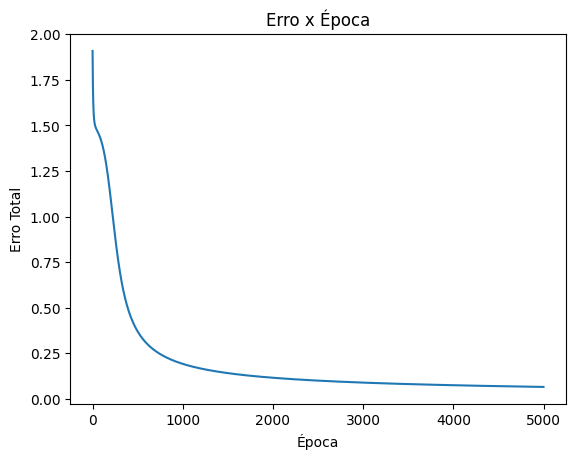

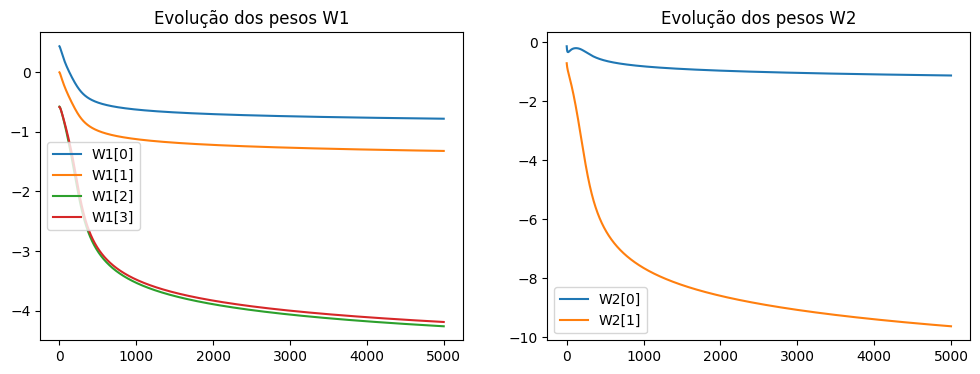

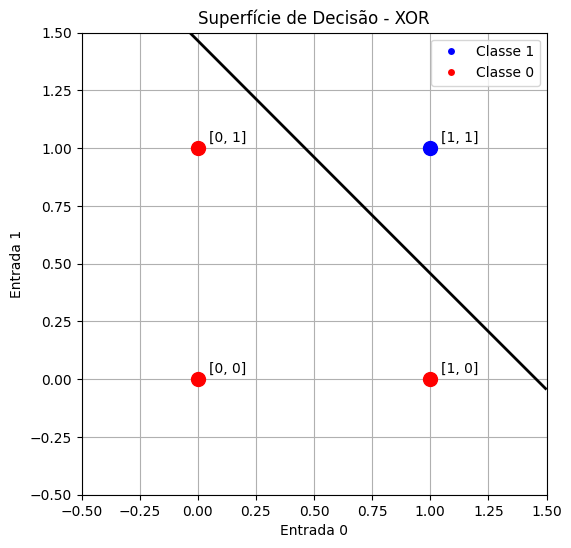



--- Teste Final ---
Entrada: [0, 0] | Alvo: 0 | Saída Rede: 0.0028
Entrada: [0, 1] | Alvo: 0 | Saída Rede: 0.0171
Entrada: [1, 0] | Alvo: 0 | Saída Rede: 0.0166
Entrada: [1, 1] | Alvo: 1 | Saída Rede: 0.9713

=== Pesos e Bias Finais ===
W1[0] = -0.781915  |  W1[1] = -1.322382
W1[2] = -4.263318  |  W1[3] = -4.191337
B1[0] = 0.177193  |  B1[1] = 5.879546
W2[0] = -1.121431  |  W2[1] = -9.627136
B2    = 4.346505


In [1]:
import numpy as np # Biblioteca que auxilia em algumas operações matemáticas.
import matplotlib.pyplot as plt # Biblioteca para geração de gráficos.
import random as rd # Biblioteca que gera números aleatórios.

def logistica(x, a=1):
    # Função Logística / Sigmoid:  σ(x) = 1 / (1 + e^(-a·x))
    return 1 / (1 + np.exp(-a * x))

def d_logistica(x, a=1):
    # Derivada da Logística:  σ'(x) = a · σ(x) · (1 - σ(x))
    s = logistica(x, a)
    return a * s * (1 - s)


# Dados de entrada e saida para simulação da porta AND.
inputs = [[0,0],[0,1],[1,0],[1,1]]
out_desejada = [0,0,0,1]

# Definindo os parâmetros da rede neural.
neuronios_entrada = 2  # Número de neurônios na camada de entrada.
neuronios_escondido = 2 # Número de neurônios na camada oculta.
neuronios_saida = 1 # Número de neurônios na camada de saída.
fator_aprendizagem = 0.5 # Taxa de aprendizado.
epocas = 5000 # Número de epocas de treinamento.

# Inicialização do pesos
W1 = [rd.uniform(-1,1),rd.uniform(-1,1),rd.uniform(-1,1),rd.uniform(-1,1)]
B1 = [rd.uniform(-1,1),rd.uniform(-1,1)]
W2 = [rd.uniform(-1,1),rd.uniform(-1,1)]
B2 = rd.uniform(-1,1)

# Treinamento da Rede Neural com 5000 epocas.

historico_W1 = []
historico_W2 = []
historico_B1 = []
historico_B2 = []
erros_epoca = []


for i in range(epocas):
  erros = 0

  for j in range(len(inputs)):

    V1_n1 = ((inputs[j][0]*W1[0] + inputs[j][1]*W1[1]) + B1[0])
    V1_n2 = ((inputs[j][0]*W1[2] + inputs[j][1]*W1[3]) + B1[1])

    # Representam caracteristicas extraidas dos dados brutos aprensentados.
    Y_n1 = logistica(V1_n1)
    Y_n2 = logistica(V1_n2)

    # Campo Local da saída.
    V2 = ((Y_n1*W2[0]+Y_n2*W2[1])) + B2
    Y_final = logistica(V2) # Saída real

    erro = out_desejada[j] - Y_final

    # Contagem dos erros
    erros += abs(erro)

    # Backpropagation
    gradiente_V2 = erro * d_logistica(V2) # Gradiente do campo local da saída
    gradiente_V1_n1 = d_logistica(V1_n1) * (gradiente_V2 * W2[0]) # Gradiente do campo local do 1 neuronio
    gradiente_V1_n2 = d_logistica(V1_n2) * (gradiente_V2 * W2[1]) # Gradiente do campo local do 2 neuronio

    # Atualização dos Pesos e BIAS
    W2[0] = W2[0] + (fator_aprendizagem * gradiente_V2 * Y_n1)
    W2[1] = W2[1] + (fator_aprendizagem * gradiente_V2 * Y_n2)
    B2 = B2 + (fator_aprendizagem * gradiente_V2)

    W1[0] = W1[0] + (fator_aprendizagem * gradiente_V1_n1 * inputs[j][0])
    W1[1] = W1[1] + (fator_aprendizagem * gradiente_V1_n1 * inputs[j][1])
    B1[0] = B1[0] + (fator_aprendizagem * gradiente_V1_n1)

    W1[2] = W1[2] + (fator_aprendizagem * gradiente_V1_n2 * inputs[j][0])
    W1[3] = W1[3] + (fator_aprendizagem * gradiente_V1_n2 * inputs[j][1])
    B1[1] = B1[1] + (fator_aprendizagem * gradiente_V1_n2)

  historico_W1.append(list(W1))
  historico_W2.append(list(W2))
  historico_B1.append(list(B1))
  historico_B2.append(float(B2))
  erros_epoca.append(erros)

# Plotagem dos Erros x Epoca

plt.plot(erros_epoca)
plt.xlabel("Época")
plt.ylabel("Erro Total")
plt.title("Erro x Época")
plt.show()

print("")

# Plotagem da evolução dos pesos

# Converte para facilitar o acesso por índice
historico_W1 = list(zip(*historico_W1))
historico_W2 = list(zip(*historico_W2))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for idx, w in enumerate(historico_W1):
    plt.plot(w, label=f"W1[{idx}]")
plt.title("Evolução dos pesos W1")
plt.legend()

plt.subplot(1, 2, 2)
for idx, w in enumerate(historico_W2):
    plt.plot(w, label=f"W2[{idx}]")
plt.title("Evolução dos pesos W2")
plt.legend()

plt.show()

print("")

# Plotagem da reta de separação das classes.

# Cria a grade
x0_range = np.linspace(-0.5, 1.5, 200)
x1_range = np.linspace(-0.5, 1.5, 200)
xx0, xx1 = np.meshgrid(x0_range, x1_range)

# Forward pass na grade
Z = []
for i in range(len(xx0)):
    linha = []
    for j in range(len(xx0[i])):
        x0 = xx0[i][j]
        x1 = xx1[i][j]
        v1_n1 = (x0*W1[0] + x1*W1[1]) + B1[0]
        v1_n2 = (x0*W1[2] + x1*W1[3]) + B1[1]
        y1 = logistica(v1_n1)
        y2 = logistica(v1_n2)
        v2 = (y1*W2[0] + y2*W2[1]) + B2
        saida = logistica(v2)
        linha.append(saida)
    Z.append(linha)

Z = np.array(Z)

# Gráfico simples
plt.figure(figsize=(6, 6))
plt.contour(xx0, xx1, Z, levels=[0.5], colors='black', linewidths=2)

cores = ['blue' if o == 1 else 'red' for o in out_desejada]
for inp, cor in zip(inputs, cores):
    plt.scatter(inp[0], inp[1], color=cor, s=100, zorder=5)
    plt.annotate(f"{inp}", (inp[0], inp[1]), textcoords="offset points", xytext=(8, 5))

plt.title("Superfície de Decisão - AND")
plt.xlabel("Entrada 0")
plt.ylabel("Entrada 1")
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='blue', label='Classe 1'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red', label='Classe 0')
])
plt.grid(True)
plt.show()

print("")

print("\n--- Teste Final ---")
for j in range(len(inputs)):
    # Faz o forward uma última vez com os pesos treinados
    v1_n1 = (inputs[j][0]*W1[0] + inputs[j][1]*W1[1]) + B1[0]
    v1_n2 = (inputs[j][0]*W1[2] + inputs[j][1]*W1[3]) + B1[1]
    y1 = logistica(v1_n1)
    y2 = logistica(v1_n2)
    v2 = (y1*W2[0] + y2*W2[1]) + B2
    final = logistica(v2)
    print(f"Entrada: {inputs[j]} | Alvo: {out_desejada[j]} | Saída Rede: {final:.4f}")

print("")

print("=== Pesos e Bias Finais ===")
print(f"W1[0] = {W1[0]:.6f}  |  W1[1] = {W1[1]:.6f}")
print(f"W1[2] = {W1[2]:.6f}  |  W1[3] = {W1[3]:.6f}")
print(f"B1[0] = {B1[0]:.6f}  |  B1[1] = {B1[1]:.6f}")
print(f"W2[0] = {W2[0]:.6f}  |  W2[1] = {W2[1]:.6f}")
print(f"B2    = {B2:.6f}")